<a href="https://colab.research.google.com/github/QbdulloK/NLP-message-user-predictor/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP User message predictor:
**The aim for this project is to predict which of my friends sent a message.**

**The model(RuBERT) will only be given the message as test data without any context.**

**In order to acquire the dataset, I took around 700 messages per person from telegram(an online messaging app) and 55 messages as test data**

**The main challenge will be that sometimes there is really no way to tell which person wrote a specific message either due to lack of words or similar styles**

**Despite that, my model managed to acheive a high accuracy which proves it actually manages to differentiate people much better than random.**

In [2]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import os
from google.colab import userdata
import random
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN') # Useful in order to download from huggingface
# Fixate the randomness
seed_number = 777
random.seed(seed_number)
torch.manual_seed(seed_number)
torch.cuda.manual_seed_all(seed_number)

In [3]:
with open('train_data.txt', 'r', encoding='utf-8') as f:
    train_data = f.read()
with open('test_data.txt', 'r', encoding='utf-8') as f:
    test_data = f.read()

USER 1 726
USER 2 698
USER 3 685


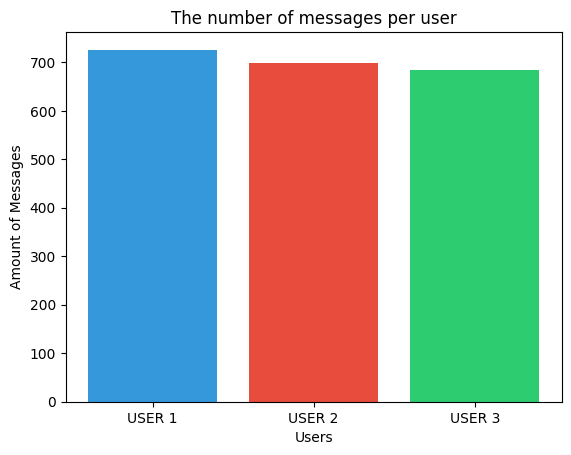

In [4]:
min_length_messages = 6
b = train_data.split('\n')
# For anonymity reasons, I labeled my friends as "USER 1", "USER 2", "USER 3"
people = ['USER 1:', 'USER 2:', 'USER 3:']
people_name = ['USER 1', 'USER 2', 'USER 3']

amount_people = len(people_name)
messages = [[] for _ in range(amount_people)]
for i in range(len(b)):
    if b[i] in people:
        person_numb = people.index(b[i])
    else:
        if len(b[i]) >= min_length_messages:
            messages[person_numb].append(b[i])
train_messages = []
train_labels = []
counts = []
for i in range(len(people_name)):
    print(people_name[i], len(messages[i]))
    counts.append(len(messages[i]))
    for elem in messages[i]:
        train_messages.append(elem)
        train_labels.append(people_name[i])
# A Bar chart that counts the number of messages per person:
plt.bar(people_name, counts, color=['#3498db', '#e74c3c', '#2ecc71'])

plt.title("The number of messages per user")
plt.xlabel("Users")
plt.ylabel("Amount of Messages")

plt.show()

**The bar chart above clearly illustrates that there are roughly an equal number of messages. There isn't any class dominating any other in quantity.**

In [5]:
bb = test_data.split('\n')
messages_test = [[] for _ in range(amount_people)]
for i in range(len(bb)):
    if bb[i] in people:
        person_numb = people.index(bb[i])
    else:
        if len(bb[i]) >= min_length_messages: # Remove and messages that are too short
            messages_test[person_numb].append(bb[i])
test_messages = []
test_messages_length = []
y_test = []
for i in range(len(people_name)):
    for elem in messages_test[i]:
        test_messages.append(elem)
        test_messages_length.append(len(elem))
        y_test.append(people_name[i])
print('Answers to test data:', y_test)

Answers to test data: ['USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3']


**Some examples of messages(in Russian):**

In [6]:
train_df = pd.DataFrame({'text': train_messages, 'label': train_labels})
train_df = train_df.drop_duplicates(subset=['text'], keep='first')
train_df = train_df.reset_index(drop=True)
print(train_df.head())

                                                text   label
0                           Афигеть да он умнее меня  USER 1
1   Ахахахахахахах пипец так можно всю игру выкупить  USER 1
2  Ух ты ну тут реально очень много учился челове...  USER 1
3  АХАХАХАХАХАХА бедная чья-то мама ахахахха сыно...  USER 1
4                        Литра егэ у моей подруги☠☠☠  USER 1


In [7]:
test_df = pd.DataFrame({'text': test_messages})
print(test_df.head())


                                text
0                       Понятно Гроб
1           Емааааааааа хорош привет
2  А во сколько сегодня контрольная?
3                   Брооооо кааааккк
4     Хахахахахах а у меня правильно


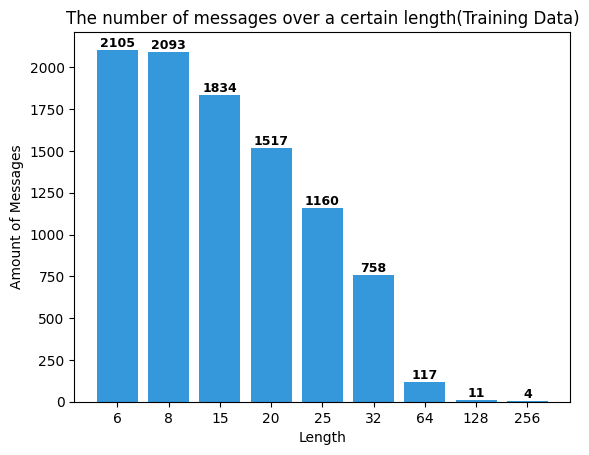

In [8]:
# Graph about the length of messages(Training Data)
length_numbers = ['6', '8', '15', '20', '25', '32', '64', '128', '256']
values = []

# Count how many messages are longer than a certain value
for val in length_numbers:
    values.append(len(train_df[train_df['text'].str.len() >= int(val)]))

bars = plt.bar(length_numbers, values, color='#3498db')

# Putting the exact numbers on top of each bar so they are easy to read
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("The number of messages over a certain length(Training Data)")
plt.xlabel("Length")
plt.ylabel("Amount of Messages")
plt.ylim(0, max(values) * 1.05)

plt.show()

**From this graph, we can observe that around half the messages are less or equal to 25 characters(since 1160 messages are above 25 that means 2105-1160=945 messages are less than 25 characters(~45%)). On top of that, 64% of the messages are less than 32 characters.**

**Also, since basically all messages are less than 256 characters, I will use 128 tokens for the Tokenizer(since 128 tokens ~ 320-450 characters)**

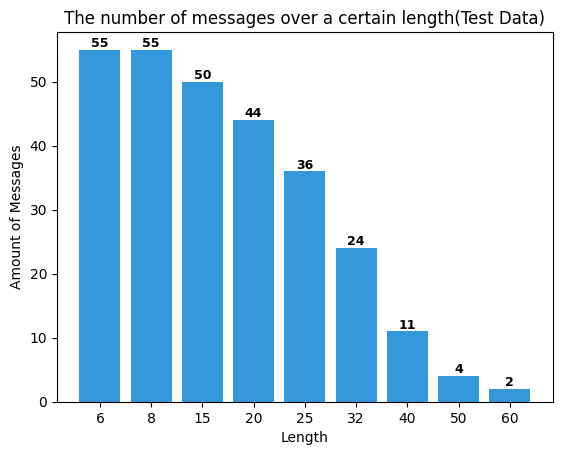

In [9]:
# Graph about the length of messages(Test Data)
length_numbers = ['6', '8', '15', '20', '25', '32', '40', '50', '60']
values = []

# Count how many messages are longer than a certain value
for val in length_numbers:
    values.append(len(test_df[test_df['text'].str.len() >= int(val)]))

bars = plt.bar(length_numbers, values, color='#3498db')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("The number of messages over a certain length(Test Data)")
plt.xlabel("Length")
plt.ylabel("Amount of Messages")
plt.ylim(0, max(values) * 1.05)

plt.show()

**In the test data, only 35% of the messages are smaller than 25 characters and 56% of the messages are smaller than 32 characters.**

**Because of this, we should see that the test accuracy could be moderately higher than the validation accuracy(since messages from the test data look like they are longer on average)**

In [10]:
le = LabelEncoder()
# Convert each USER into a number("0", "1", "2")
train_df['label'] = le.fit_transform(train_df['label'])
num_classes = train_df['label'].nunique()

# Using Rubert instead of Bert since basically all messages are in Russian
Tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')

train_encodings = Tokenizer(train_df['text'].tolist(), padding=True, truncation=True, max_length=128, return_tensors='pt')

test_encodings = Tokenizer(test_df['text'].tolist(), padding=True, truncation=True, max_length=128, return_tensors='pt')
print('Done')

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Done


In [11]:
# Using stratify just in case
# Even though there are a roughly equal number of messages per person
X_train, X_val, X_train_mask, X_val_mask, y_train, y_val = train_test_split(train_encodings['input_ids'],
                                                                            train_encodings['attention_mask'],
                                                                            train_df['label'].values,
                                                                            test_size=0.2,
                                                                            random_state=seed_number,
                                                                            stratify=train_df['label'].values
                                                                            )

y_train = torch.LongTensor(y_train)
y_val = torch.LongTensor(y_val)

train_dataset = TensorDataset(X_train, X_train_mask, y_train)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# Divide the messages into groups of 32

print("Downloading RuBert")

model = AutoModelForSequenceClassification.from_pretrained(
    'DeepPavlov/rubert-base-cased',
    num_labels=num_classes,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Freeze every layer of bert
for param in model.bert.parameters():
    param.requires_grad = False

print(device)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

cuda


In [12]:
# We only optimise the classifier
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=5e-4, weight_decay=0.01)

best_acc = -1
epoch_amount = 10

history_loss = []
history_accuracy = []

for epoch in range(epoch_amount):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        # Let the model guess who wrote the batch of messages

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss

        optimizer.zero_grad() # Zeroing the gradient so that the model doesnt get intefered by previous iterations

        loss.backward() # Calculate backpropagation

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # "Normalize" the parameters so that the gradients dont explode

        optimizer.step() # Move towards the correct direction(Gradient Descent)

        total_loss += loss.item()


    model.eval()

    with torch.no_grad():
        val_outputs = model(input_ids=X_val.to(device), attention_mask=X_val_mask.to(device))
        val_preds = torch.argmax(val_outputs.logits, dim=1)
        accuracy = (val_preds.cpu() == y_val).float().mean() # Calculate the validation accuracy

    history_loss.append(total_loss / len(train_loader))
    history_accuracy.append(accuracy)

    print(epoch+1, total_loss / len(train_loader), accuracy)

    if accuracy > best_acc:
      best_acc = accuracy
      torch.save(model.state_dict(), 'best_model.pth')

model.load_state_dict(torch.load('best_model.pth'))


100%|██████████| 53/53 [00:09<00:00,  5.32it/s]


1 1.0940440150926698 tensor(0.3895)


100%|██████████| 53/53 [00:08<00:00,  6.00it/s]


2 1.0918118796258602 tensor(0.4323)


100%|██████████| 53/53 [00:08<00:00,  5.91it/s]


...

100%|██████████| 53/53 [00:09<00:00,  5.31it/s]


9 1.049953650753453 tensor(0.5202)


100%|██████████| 53/53 [00:09<00:00,  5.52it/s]


10 1.041707288544133 tensor(0.5439)


<All keys matched successfully>

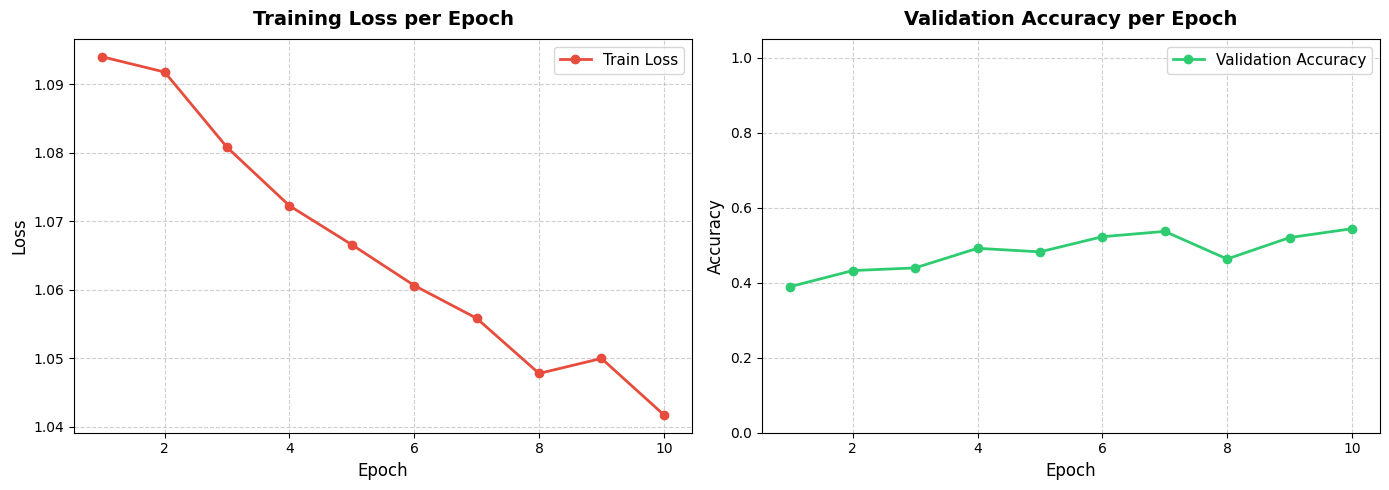

In [13]:
# Line graph showing the loss and val accuracy:
epochs_range = range(1, epoch_amount + 1)

plt.figure(figsize=(14, 5))

# Graph Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_loss, label='Train Loss', color='#E74C3C', linewidth=2, marker='o')
plt.title('Training Loss per Epoch', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Graph Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_accuracy, label='Validation Accuracy', color='#2ECC71', linewidth=2, marker='o')
plt.title('Validation Accuracy per Epoch', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

**From the line graphs above, we can see that the loss and validation accuracy was slightly fluctuating and that the val accuracy reached around 54% at the end.**

In [14]:
model.eval()
with torch.no_grad():
    outputs = model(input_ids=test_encodings['input_ids'].to(device), attention_mask=test_encodings['attention_mask'].to(device))
    probabilities = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    pred = np.argmax(probabilities, axis=1)

predictions = le.inverse_transform(pred)

res = pd.DataFrame({'label': predictions})
res.to_csv('submission.csv', index=False)

print("Guesses:")
conf_before = []
for i in range(len(predictions)):
    print('Message #' + str(i+1))
    print('  Guess:', predictions[i])
    print("  Confidence by users:")
    for j, cls in enumerate(le.classes_):
        if cls == predictions[i]:
          conf_before.append(round(100 * probabilities[i][j], 2))
        print('    ' + cls + ':', str(round(100 * probabilities[i][j], 2)) + '%')
print('-----------------------------------------')
print('Accuracy:', str(round(100 * accuracy_score(predictions, y_test), 2)) + '%')

Guesses:
Message #1
  Guess: USER 1
  Confidence by users:
    USER 1: 38.12%
    USER 2: 29.5%
    USER 3: 32.38%
Message #2
  Guess: USER 2
  Confidence by users:
    USER 1: 32.13%
    USER 2: 37.41%
    USER 3: 30.46%
Message #3
  Guess: USER 3
  Confidence by users:
    USER 1: 33.75%
    USER 2: 27.17%
    USER 3: 39.09%
Message #4
  Guess: USER 1
  Confidence by users:
    USER 1: 52.04%
    USER 2: 24.61%
    USER 3: 23.34%
Message #5
  Guess: USER 1
  Confidence by users:
    USER 1: 59.53%
    USER 2: 23.18%
    USER 3: 17.29%
Message #6
  Guess: USER 1
  Confidence by users:
    USER 1: 36.83%
    USER 2: 28.2%
    USER 3: 34.97%
Message #7
  Guess: USER 3
  Confidence by users:
    USER 1: 30.22%
    USER 2: 33.8%
    USER 3: 35.98%
Message #8
  Guess: USER 1
  Confidence by users:
    USER 1: 45.94%
    USER 2: 23.67%
    USER 3: 30.39%
Message #9
  Guess: USER 1
  Confidence by users:
    USER 1: 53.37%
    USER 2: 28.68%
    USER 3: 17.95%
Message #10
  Guess: USER 1
  C

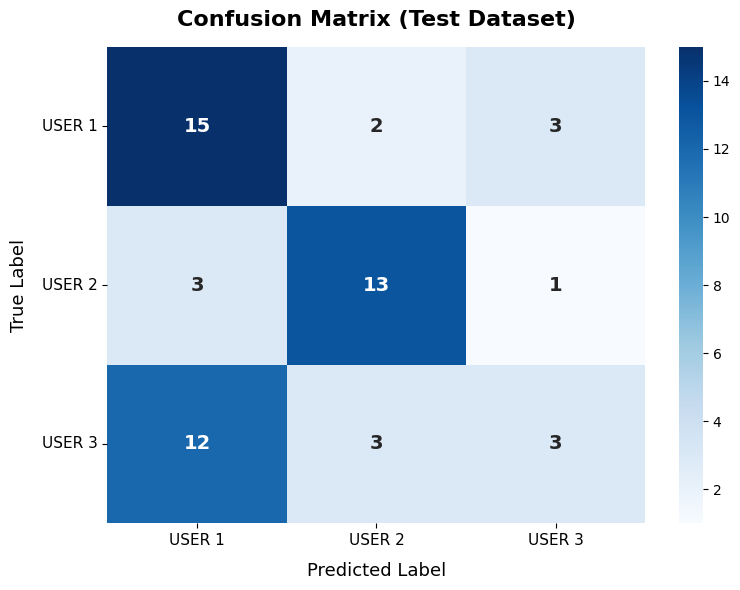

In [15]:
# Confusion Matrix:
y_test_encoded = le.transform(y_test)
cm = confusion_matrix(y_test_encoded, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix (Test Dataset)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=13, labelpad=10)
plt.ylabel('True Label', fontsize=13, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

**This confusion matrix indicates that the model(Before Fine-Tuning) has a hard time distinguishing USER 3 and that the model tends to see similarities with USER 1 and USER 3. But, the model seems to effortlessly understand the style of USER 2.**

**In the end, the model reached an accuracy of 56.4% which is similar to the 54% acheived in the val accuracy.**

# Fine-Tuning the model
**Now we will load the model and transition from training only the FC layer to training across all layers.**

**This approach(Two-Stage Training) is significantly more effective than running a single training loop.**

**The core reason is to stabilize and adapt the final classification layer first. Doing so prevents catastrophic forgetting, preserving the valuable pre-trained features in the earlier layers before we adjust the entire network.**

In [16]:
# Fine Tuning the Model:
model.load_state_dict(torch.load('best_model.pth'))

# Now we unfreeze every layer in order to train the entire model

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-6, weight_decay=0.1)
# We decrease the lr and increase weight decay
# because of all the new parameters that we need to tune

epoch_amount = 12

history_loss = []
history_accuracy = []

for epoch in range(epoch_amount):
    # Same training loop as before
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()


    model.eval()

    with torch.no_grad():
        val_outputs = model(input_ids=X_val.to(device), attention_mask=X_val_mask.to(device))
        val_preds = torch.argmax(val_outputs.logits, dim=1)
        accuracy = (val_preds.cpu() == y_val).float().mean()

    history_loss.append(total_loss / len(train_loader))
    history_accuracy.append(accuracy)

    print(epoch+1, total_loss / len(train_loader), accuracy)

    if accuracy >= best_acc:
      best_acc = accuracy
      torch.save(model.state_dict(), 'best_model.pth')

model.load_state_dict(torch.load('best_model.pth'))

100%|██████████| 53/53 [00:31<00:00,  1.68it/s]


1 1.0157658907602418 tensor(0.5368)


100%|██████████| 53/53 [00:30<00:00,  1.72it/s]


2 0.9491305373749643 tensor(0.5701)


100%|██████████| 53/53 [00:31<00:00,  1.70it/s]


...

100%|██████████| 53/53 [00:30<00:00,  1.74it/s]


11 0.5138360942309758 tensor(0.6342)


100%|██████████| 53/53 [00:30<00:00,  1.71it/s]


12 0.4668633189966094 tensor(0.6366)


<All keys matched successfully>

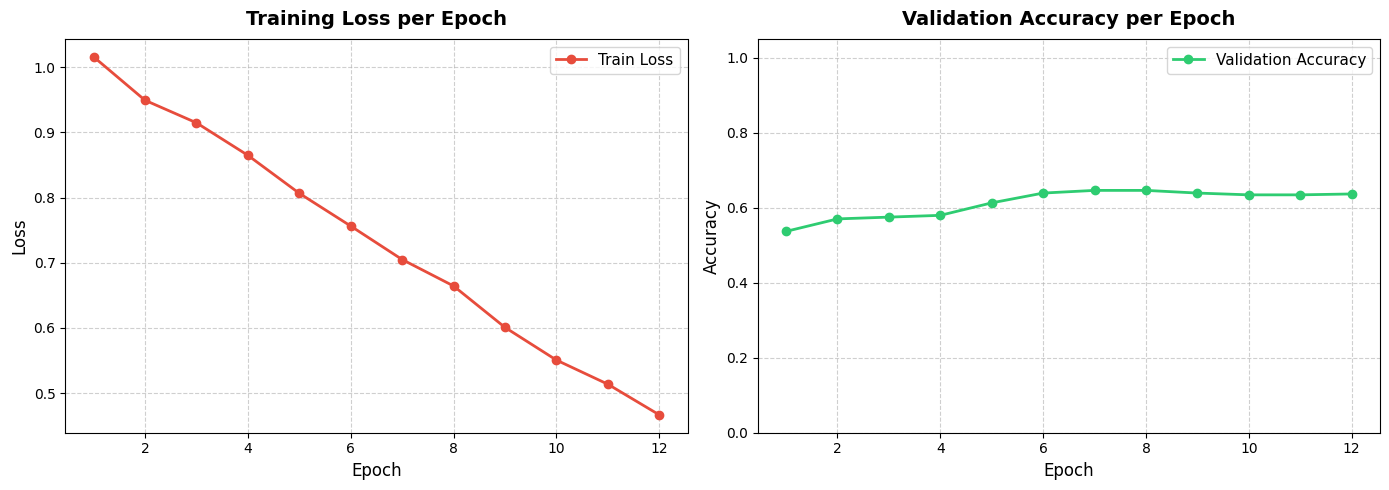

In [17]:
epochs_range = range(1, epoch_amount + 1)

plt.figure(figsize=(14, 5))

# Graph Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_loss, label='Train Loss', color='#E74C3C', linewidth=2, marker='o')
plt.title('Training Loss per Epoch', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Graph Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_accuracy, label='Validation Accuracy', color='#2ECC71', linewidth=2, marker='o')
plt.title('Validation Accuracy per Epoch', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

**The line graphs above prove that the Fine-Tuning approach was beneficial.**
**Not only did Loss function decrease dramatically(unlike a slight fall from the FC training loop) the accuracy jumped to around 64% in the validation data.**

In [18]:
model.eval()
with torch.no_grad():
    outputs = model(input_ids=test_encodings['input_ids'].to(device), attention_mask=test_encodings['attention_mask'].to(device))
    probabilities = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    pred = np.argmax(probabilities, axis=1)

predictions = le.inverse_transform(pred)

res = pd.DataFrame({'label': predictions})
res.to_csv('submission.csv', index=False)

print("Guesses:")
conf_after = []
for i in range(len(predictions)):
    print('Message #' + str(i+1))
    print('  Guess:', predictions[i])
    print("  Confidence by users:")
    for j, cls in enumerate(le.classes_):
        if cls == predictions[i]:
          conf_after.append(round(100 * probabilities[i][j], 2))
        print('    ' + cls + ':', str(round(100 * probabilities[i][j], 2)) + '%')
print('-----------------------------------------')
print('Accuracy:', str(round(100 * accuracy_score(predictions, y_test), 2)) + '%')

Guesses:
Message #1
  Guess: USER 1
  Confidence by users:
    USER 1: 67.09%
    USER 2: 13.37%
    USER 3: 19.54%
Message #2
  Guess: USER 1
  Confidence by users:
    USER 1: 53.28%
    USER 2: 22.1%
    USER 3: 24.62%
Message #3
  Guess: USER 3
  Confidence by users:
    USER 1: 33.65%
    USER 2: 19.82%
    USER 3: 46.52%
Message #4
  Guess: USER 1
  Confidence by users:
    USER 1: 85.28%
    USER 2: 7.57%
    USER 3: 7.14%
Message #5
  Guess: USER 1
  Confidence by users:
    USER 1: 94.04%
    USER 2: 4.17%
    USER 3: 1.79%
Message #6
  Guess: USER 1
  Confidence by users:
    USER 1: 61.83%
    USER 2: 25.82%
    USER 3: 12.35%
Message #7
  Guess: USER 3
  Confidence by users:
    USER 1: 6.22%
    USER 2: 44.86%
    USER 3: 48.93%
Message #8
  Guess: USER 1
  Confidence by users:
    USER 1: 74.75%
    USER 2: 6.63%
    USER 3: 18.62%
Message #9
  Guess: USER 1
  Confidence by users:
    USER 1: 87.8%
    USER 2: 8.63%
    USER 3: 3.57%
Message #10
  Guess: USER 3
  Confiden

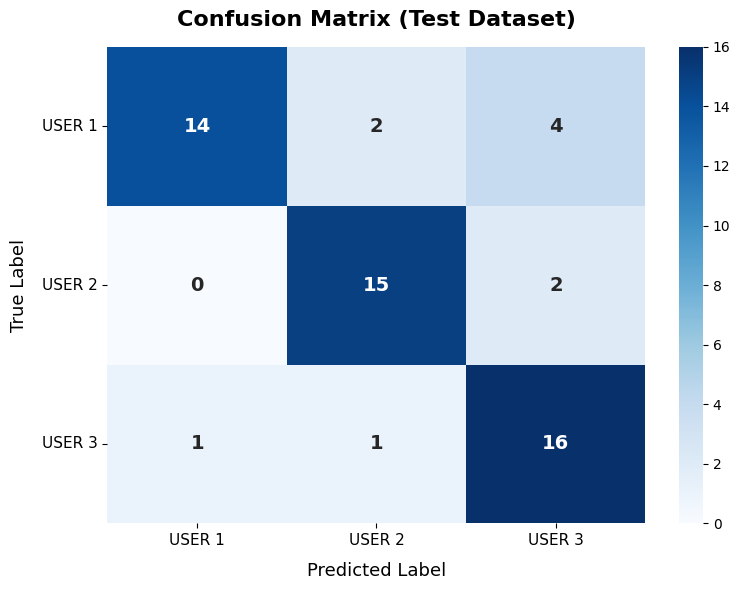

In [19]:
# Confusion Matrix:
y_test_encoded = le.transform(y_test)
cm = confusion_matrix(y_test_encoded, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix (Test Dataset)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=13, labelpad=10)
plt.ylabel('True Label', fontsize=13, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

**The matrix above shows that the model(After Fine-Tuning) is now much better in determining the styles of every person with barely any inaccuracies. Furthermore, the model's accuracy on the test data boosted up to 82%. One of the main reasons why the validation accuracy and test accuracy differ so much is that the test messages are longer, on average, which means that the model has more data to work with and was able to predict a lot more accurately.**

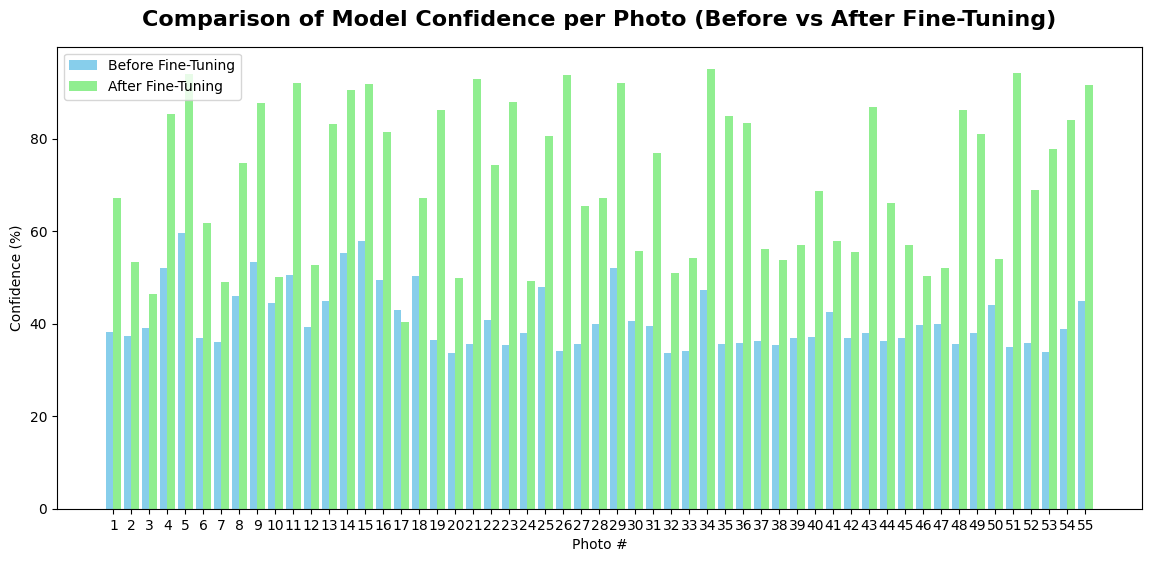

In [20]:
# Bar chart showing the confidence of the model before and after fine-tuning:
x = np.arange(1, len(y_test) + 1)

plt.figure(figsize=(14, 6))

plt.bar(x - 0.2, conf_before, width=0.4, label='Before Fine-Tuning', color='skyblue')

plt.bar(x + 0.2, conf_after, width=0.4, label='After Fine-Tuning', color='lightgreen')

plt.title('Comparison of Model Confidence per Photo (Before vs After Fine-Tuning)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(x)
plt.ylabel('Confidence (%)')
plt.xlabel('Photo #')
plt.legend()

plt.show()

**This chart also shows that the model's confidence score shot up in the majority of cases. For instance, messages #11,#34, and #51 confidence went from 50%, 47% and 35%(which is slightly better than random) up to 92%, 95% and 84% respectively.**

# Simulating other scenarios:
**I wrote a function run_code_simulation with three parameters(user1, user2, user3) that should be either True or False which means it should either be included or excluded from the simulation**
**I wanted to test how well the model could distinguish 2 people instead of 3.**

In [26]:
# @title
# This function simulates the entire learning process:
def run_code_simulation(user1=True, user2=True, user3=True):
    seed_number = 777
    random.seed(seed_number)
    torch.manual_seed(seed_number)
    torch.cuda.manual_seed_all(seed_number)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    active_users = []
    active_prefixes = []
    if user1:
        active_users.append('USER 1')
        active_prefixes.append('USER 1:')
    if user2:
        active_users.append('USER 2')
        active_prefixes.append('USER 2:')
    if user3:
        active_users.append('USER 3')
        active_prefixes.append('USER 3:')

    num_classes = len(active_users)
    print('Simulating with', num_classes, 'users:', active_users)

    with open('train_data.txt', 'r', encoding='utf-8') as f:
        train_raw = f.read().split('\n')
    with open('test_data.txt', 'r', encoding='utf-8') as f:
        test_raw = f.read().split('\n')

    min_length_messages = 6

    train_messages = []
    train_labels = []
    current_person = None

    for line in train_raw:
        if line in ['USER 1:', 'USER 2:', 'USER 3:']:
            if line in active_prefixes:
                current_person = line.replace(':', '')
            else:
                current_person = None
        elif current_person is not None:
            if len(line) >= min_length_messages:
                train_messages.append(line)
                train_labels.append(current_person)

    test_messages = []
    y_test = []
    current_person = None

    for line in test_raw:
        if line in ['USER 1:', 'USER 2:', 'USER 3:']:
            if line in active_prefixes:
                current_person = line.replace(':', '')
            else:
                current_person = None
        elif current_person is not None:
            if len(line) >= min_length_messages:
                test_messages.append(line)
                y_test.append(current_person)
    print('Answers to test data:', y_test)
    train_df = pd.DataFrame({'text': train_messages, 'label': train_labels})
    train_df = train_df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
    test_df = pd.DataFrame({'text': test_messages})
    print('Train data:')
    print(train_df.head())
    print('Test data:')
    print(test_df.head())
    counts = [len(train_df[train_df['label'] == user]) for user in active_users]
    plt.figure(figsize=(6, 4))
    plt.bar(active_users, counts, color=['#3498db', '#e74c3c', '#2ecc71'][:num_classes])
    plt.title("The number of messages per user")
    plt.xlabel("Users")
    plt.ylabel("Amount of Messages")
    plt.show()

    le = LabelEncoder()
    train_df['label'] = le.fit_transform(train_df['label'])
    y_test_encoded = le.transform(y_test)

    tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')

    train_encodings = tokenizer(train_df['text'].tolist(), padding=True, truncation=True, max_length=128, return_tensors='pt')
    test_encodings = tokenizer(test_df['text'].tolist(), padding=True, truncation=True, max_length=128, return_tensors='pt')

    X_train, X_val, X_train_mask, X_val_mask, y_train, y_val = train_test_split(
        train_encodings['input_ids'],
        train_encodings['attention_mask'],
        train_df['label'].values,
        test_size=0.2,
        random_state=seed_number,
        stratify=train_df['label'].values
    )

    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)

    train_dataset = TensorDataset(X_train, X_train_mask, y_train)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    print("Downloading Rubert")
    model = AutoModelForSequenceClassification.from_pretrained(
        'DeepPavlov/rubert-base-cased',
        num_labels=num_classes,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1
    ).to(device)

    print("Stage 1(Before Fine-Tuning):")
    for param in model.bert.parameters():
        param.requires_grad = False

    optimizer_s1 = torch.optim.AdamW(model.classifier.parameters(), lr=5e-4, weight_decay=0.01)

    best_acc = -1
    epochs_s1 = 10
    history_loss_s1 = []
    history_accuracy_s1 = []

    for epoch in range(epochs_s1):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader):
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer_s1.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer_s1.step()
            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_outputs = model(input_ids=X_val.to(device), attention_mask=X_val_mask.to(device))
            val_preds = torch.argmax(val_outputs.logits, dim=1)
            accuracy = (val_preds.cpu() == y_val).float().mean().item()

        history_loss_s1.append(total_loss / len(train_loader))
        history_accuracy_s1.append(accuracy)
        print(epoch+1, total_loss / len(train_loader), accuracy)
        if accuracy > best_acc:
            best_acc = accuracy
            torch.save(model.state_dict(), 'best_model_temp.pth')

    # Line graph showing the loss and val accuracy for Stage 1
    epochs_range_s1 = range(1, epochs_s1 + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range_s1, history_loss_s1, label='Train Loss', color='#E74C3C', linewidth=2, marker='o')
    plt.title('Training Loss per Epoch (Stage 1)', fontsize=14, fontweight='bold', pad=10)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range_s1, history_accuracy_s1, label='Validation Accuracy', color='#2ECC71', linewidth=2, marker='o')
    plt.title('Validation Accuracy per Epoch (Stage 1)', fontsize=14, fontweight='bold', pad=10)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    # Evaluation on Test Dataset (Stage 1)
    model.load_state_dict(torch.load('best_model_temp.pth'))
    model.eval()
    with torch.no_grad():
        test_outputs = model(input_ids=test_encodings['input_ids'].to(device), attention_mask=test_encodings['attention_mask'].to(device))
        probs_s1 = torch.softmax(test_outputs.logits, dim=1).cpu().numpy()
        preds_s1 = np.argmax(probs_s1, axis=1)

    predictions_s1_decoded = le.inverse_transform(preds_s1)

    # Printing Stage 1 Guesses
    print("Guesses (Before Fine-Tuning):")
    conf_before = []
    for i in range(len(predictions_s1_decoded)):
        print('Message #' + str(i+1))
        print('  Guess:', predictions_s1_decoded[i])
        print("  Confidence by users:")
        for j, cls in enumerate(le.classes_):
            if cls == predictions_s1_decoded[i]:
                conf_before.append(round(100 * probs_s1[i][j], 2))
            print('    ' + cls + ':', str(round(100 * probs_s1[i][j], 2)) + '%')

    accuracy_before = accuracy_score(preds_s1, y_test_encoded)
    print(f"Accuracy (Before Fine-Tuning):", str(round(100*accuracy_before, 2)) + '%')

    # Confusion Matrix (Stage 1)
    cm_s1 = confusion_matrix(y_test_encoded, preds_s1)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Oranges',
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={"size": 14, "weight": "bold"})
    plt.title('Confusion Matrix (Stage 1 - Before Fine-Tuning)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=13, labelpad=10)
    plt.ylabel('True Label', fontsize=13, labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11, rotation=0)
    plt.tight_layout()
    plt.show()

    print("Stage 2: Fine-Tuning")
    for param in model.parameters():
        param.requires_grad = True

    optimizer_s2 = torch.optim.AdamW(model.parameters(), lr=2.5e-6, weight_decay=0.1)

    epochs_s2 = 12
    history_loss_s2 = []
    history_accuracy_s2 = []

    for epoch in range(epochs_s2):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader):
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            optimizer_s2.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer_s2.step()
            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_outputs = model(input_ids=X_val.to(device), attention_mask=X_val_mask.to(device))
            val_preds = torch.argmax(val_outputs.logits, dim=1)
            accuracy = (val_preds.cpu() == y_val).float().mean().item()

        history_loss_s2.append(total_loss / len(train_loader))
        history_accuracy_s2.append(accuracy)
        print(epoch+1, total_loss/len(train_loader), accuracy)
        if accuracy >= best_acc:
            best_acc = accuracy
            torch.save(model.state_dict(), 'best_model_temp.pth')

    # Line graph showing the loss and val accuracy for Stage 2
    epochs_range_s2 = range(1, epochs_s2 + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range_s2, history_loss_s2, label='Train Loss', color='#E74C3C', linewidth=2, marker='o')
    plt.title('Training Loss per Epoch (Stage 2)', fontsize=14, fontweight='bold', pad=10)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range_s2, history_accuracy_s2, label='Validation Accuracy', color='#2ECC71', linewidth=2, marker='o')
    plt.title('Validation Accuracy per Epoch (Stage 2)', fontsize=14, fontweight='bold', pad=10)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    # Evaluation on Test Dataset (Stage 2)
    model.load_state_dict(torch.load('best_model_temp.pth'))
    model.eval()
    with torch.no_grad():
        test_outputs = model(input_ids=test_encodings['input_ids'].to(device), attention_mask=test_encodings['attention_mask'].to(device))
        probs_s2 = torch.softmax(test_outputs.logits, dim=1).cpu().numpy()
        preds_s2 = np.argmax(probs_s2, axis=1)

    predictions_s2_decoded = le.inverse_transform(preds_s2)

    # Printing Stage 2 Guesses
    print("Guesses (After Fine-Tuning):")
    conf_after = []
    for i in range(len(predictions_s2_decoded)):
        print('Message #' + str(i+1))
        print('  Guess:', predictions_s2_decoded[i])
        print("  Confidence by users:")
        for j, cls in enumerate(le.classes_):
            if cls == predictions_s2_decoded[i]:
                conf_after.append(round(100 * probs_s2[i][j], 2))
            print('    ' + cls + ':', str(round(100 * probs_s2[i][j], 2)) + '%')

    accuracy_after = accuracy_score(preds_s2, y_test_encoded)
    print("Accuracy(After Fine-Tuning):", str(round(100*accuracy_after, 2)) + '%')

    # Confusion Matrix (Stage 2)
    cm_s2 = confusion_matrix(y_test_encoded, preds_s2)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={"size": 14, "weight": "bold"})
    plt.title('Confusion Matrix (Stage 2 - After Fine-Tuning)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=13, labelpad=10)
    plt.ylabel('True Label', fontsize=13, labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11, rotation=0)
    plt.tight_layout()
    plt.show()

    # Bar chart showing the confidence comparison
    x_axis = np.arange(1, len(y_test) + 1)
    plt.figure(figsize=(14, 6))
    plt.bar(x_axis - 0.2, conf_before, width=0.4, label='Before Fine-Tuning', color='skyblue')
    plt.bar(x_axis + 0.2, conf_after, width=0.4, label='After Fine-Tuning', color='lightgreen')
    plt.title('Comparison of Model Confidence per Message (Before vs After Fine-Tuning)', fontsize=16, fontweight='bold', pad=15)
    plt.xticks(x_axis)
    plt.ylabel('Confidence (%)')
    plt.xlabel('Message #')
    plt.legend()
    plt.show()

    if os.path.exists('best_model_temp.pth'):
        os.remove('best_model_temp.pth')

Simulating with 2 users: ['USER 1', 'USER 2']
Answers to test data: ['USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1']
Train data:
                                                text   label
0                           Афигеть да он умнее меня  USER 1
1   Ахахахахахахах пипец так можно всю игру выкупить  USER 1
2  Ух ты ну тут реально очень много учился челове...  USER 1
3  АХАХАХАХАХАХА бедная чья-то мама ахахахха сыно...  USER 1
4                        Литра егэ у моей подруги☠☠☠  USER 1
Test data:
                                                text
0     Хорошо, тогда удачи тебе теперь на информатике
1  Помнишь видео с роблоксом? Вот я такое буду сн...
2  Скиньте по

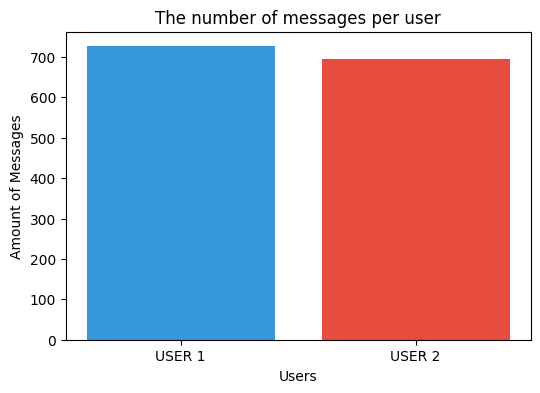

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

Stage 1(Before Fine-Tuning):


100%|██████████| 36/36 [00:06<00:00,  5.43it/s]


1 0.6925219082170062 0.5122807025909424


...

8 0.6509995195600722 0.6280701756477356


100%|██████████| 36/36 [00:06<00:00,  5.60it/s]


9 0.6506835023562113 0.6315789222717285


100%|██████████| 36/36 [00:06<00:00,  5.65it/s]


10 0.6477362083064185 0.659649133682251


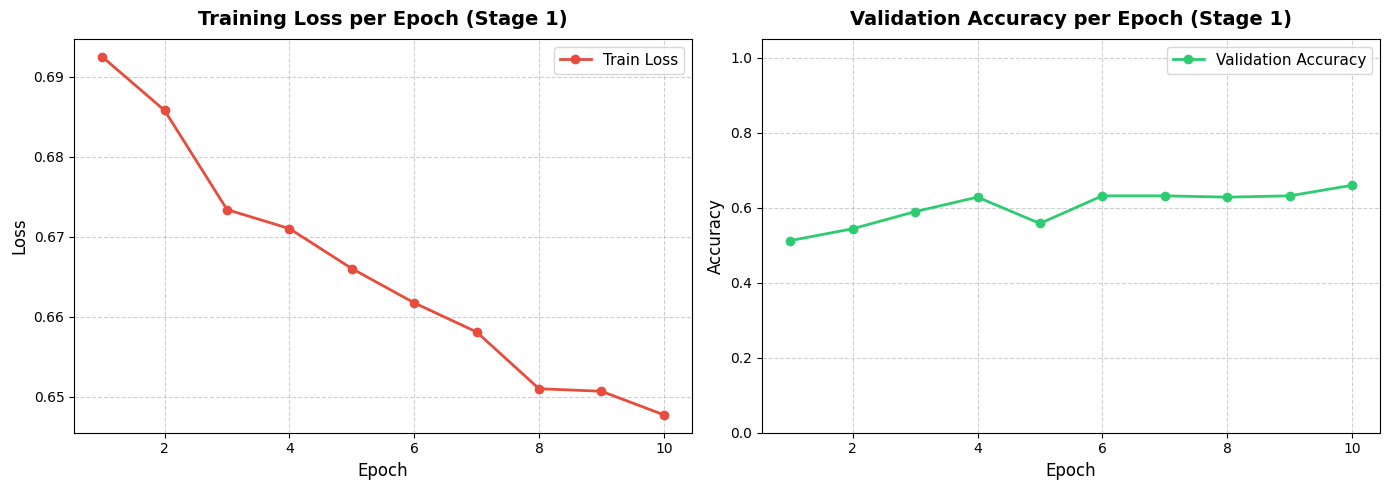

Guesses (Before Fine-Tuning):
Message #1
  Guess: USER 2
  Confidence by users:
    USER 1: 45.15%
    USER 2: 54.85%
Message #2
  Guess: USER 2
  Confidence by users:
    USER 1: 35.58%
    USER 2: 64.42%
Message #3
  Guess: USER 2
  Confidence by users:
    USER 1: 48.4%
    USER 2: 51.6%
Message #4
  Guess: USER 2
  Confidence by users:
    USER 1: 41.45%
    USER 2: 58.55%
Message #5
  Guess: USER 2
  Confidence by users:
    USER 1: 34.23%
    USER 2: 65.77%
Message #6
  Guess: USER 2
  Confidence by users:
    USER 1: 46.1%
    USER 2: 53.9%
Message #7
  Guess: USER 2
  Confidence by users:
    USER 1: 43.0%
    USER 2: 57.0%
Message #8
  Guess: USER 2
  Confidence by users:
    USER 1: 43.58%
    USER 2: 56.42%
Message #9
  Guess: USER 2
  Confidence by users:
    USER 1: 27.71%
    USER 2: 72.29%
Message #10
  Guess: USER 2
  Confidence by users:
    USER 1: 35.09%
    USER 2: 64.91%
Message #11
  Guess: USER 1
  Confidence by users:
    USER 1: 51.44%
    USER 2: 48.56%
Messag

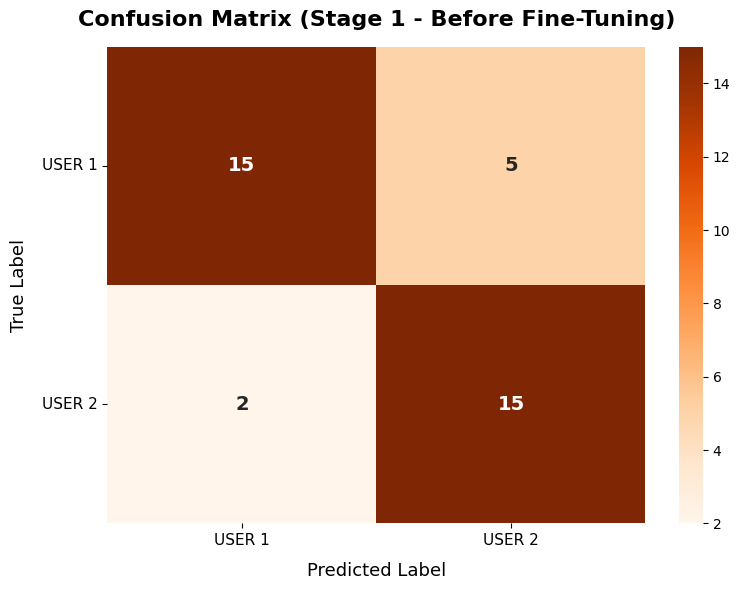

Stage 2: Fine-Tuning


100%|██████████| 36/36 [00:20<00:00,  1.74it/s]


1 0.6363141222132577 0.6842105388641357


100%|██████████| 36/36 [00:20<00:00,  1.73it/s]


2 0.5904902186658647 0.7087719440460205


...

10 0.3165311995479796 0.7157894968986511


100%|██████████| 36/36 [00:20<00:00,  1.75it/s]


11 0.2871822098063098 0.7052631378173828


100%|██████████| 36/36 [00:20<00:00,  1.73it/s]


12 0.23297014004654354 0.7333333492279053


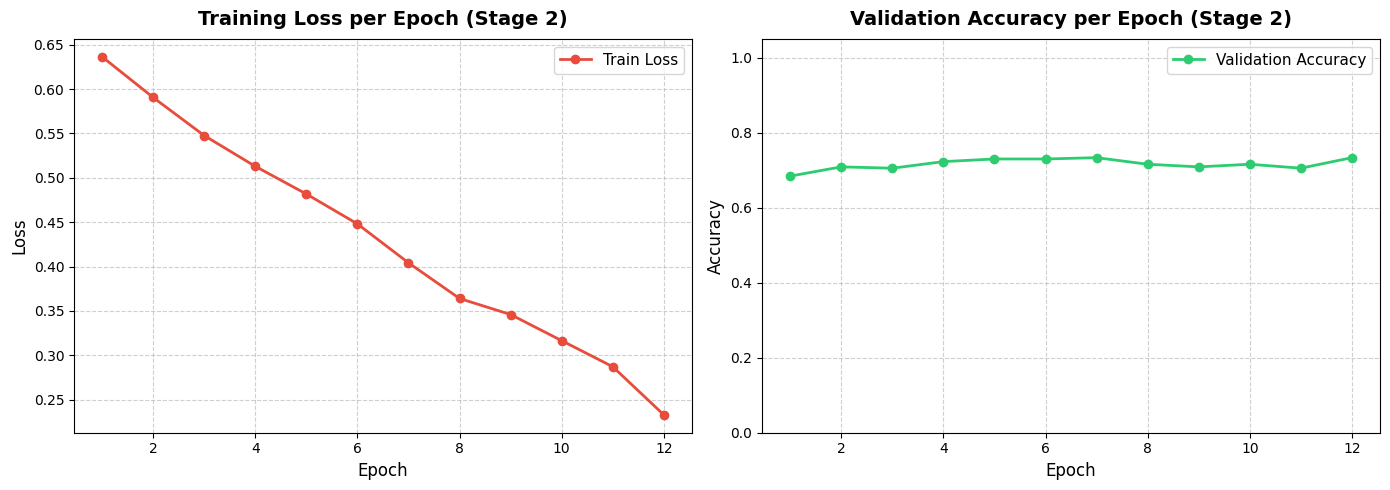

Guesses (After Fine-Tuning):
Message #1
  Guess: USER 2
  Confidence by users:
    USER 1: 0.1%
    USER 2: 99.9%
Message #2
  Guess: USER 2
  Confidence by users:
    USER 1: 0.65%
    USER 2: 99.35%
Message #3
  Guess: USER 2
  Confidence by users:
    USER 1: 0.4%
    USER 2: 99.6%
Message #4
  Guess: USER 2
  Confidence by users:
    USER 1: 1.03%
    USER 2: 98.97%
Message #5
  Guess: USER 2
  Confidence by users:
    USER 1: 5.17%
    USER 2: 94.83%
Message #6
  Guess: USER 2
  Confidence by users:
    USER 1: 0.41%
    USER 2: 99.59%
Message #7
  Guess: USER 2
  Confidence by users:
    USER 1: 3.85%
    USER 2: 96.15%
Message #8
  Guess: USER 2
  Confidence by users:
    USER 1: 4.89%
    USER 2: 95.11%
Message #9
  Guess: USER 2
  Confidence by users:
    USER 1: 0.97%
    USER 2: 99.03%
Message #10
  Guess: USER 2
  Confidence by users:
    USER 1: 0.56%
    USER 2: 99.44%
Message #11
  Guess: USER 2
  Confidence by users:
    USER 1: 32.83%
    USER 2: 67.17%
Message #12
  G

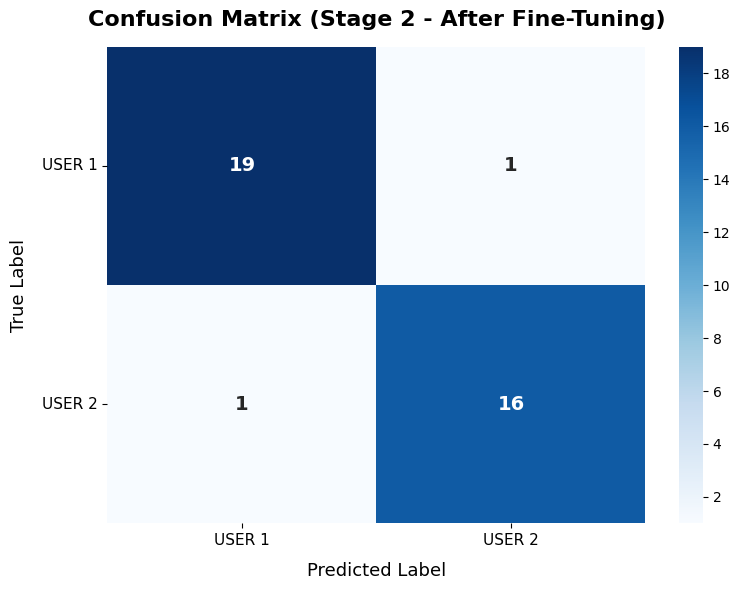

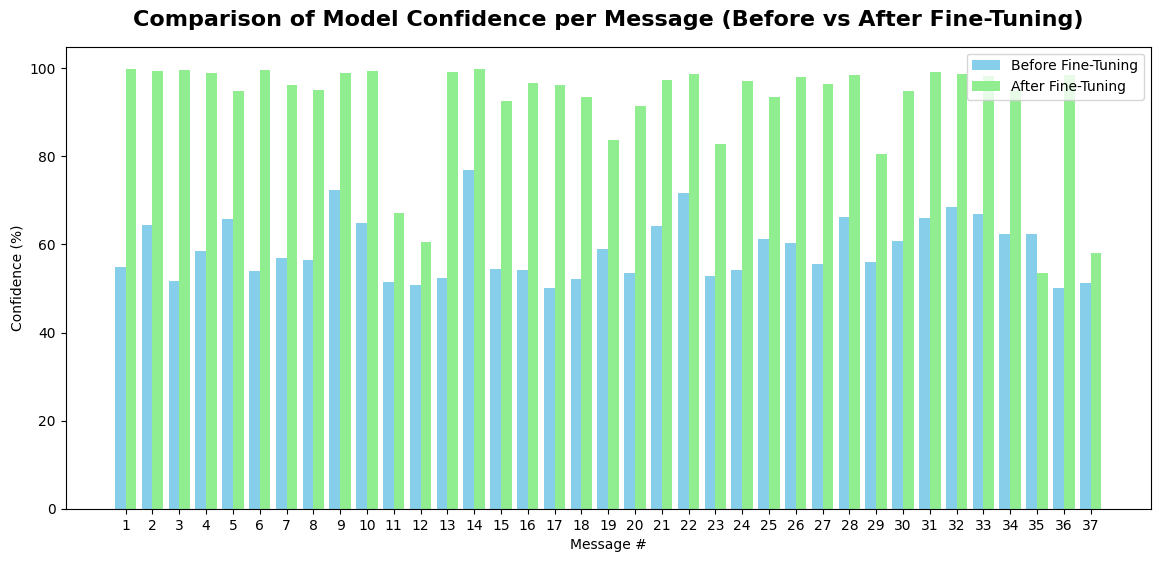

In [27]:
run_code_simulation(True, True, False)
# USER 1 vs USER 2

**The model(Before Fine-Tuning) acheived a validation accuracy of 66% and 81% in the test accuracy and the model(After Fine-Tuning) was able to reach 73% val accuracy and 95% test accuracy. Also, the confidence of the majority of the messages exceeds 90% which shows that model is easily able to tell apart USER 1 and USER 2 apart.**

Simulating with 2 users: ['USER 1', 'USER 3']
Answers to test data: ['USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 1', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3']
Train data:
                                                text   label
0                           Афигеть да он умнее меня  USER 1
1   Ахахахахахахах пипец так можно всю игру выкупить  USER 1
2  Ух ты ну тут реально очень много учился челове...  USER 1
3  АХАХАХАХАХАХА бедная чья-то мама ахахахха сыно...  USER 1
4                        Литра егэ у моей подруги☠☠☠  USER 1
Test data:
                                text
0                       Понятно Гроб
1           Емааааааааа хорош привет
2  А во сколько сегодня контрольная?
3             

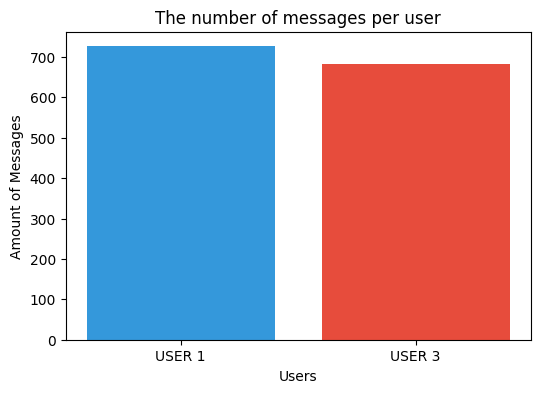

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

Stage 1(Before Fine-Tuning):


100%|██████████| 36/36 [00:06<00:00,  5.85it/s]


1 0.6932366755273607 0.5070921778678894


...

8 0.6429222317205535 0.6205673813819885


100%|██████████| 36/36 [00:06<00:00,  5.77it/s]


9 0.6478278819057677 0.6418439745903015


100%|██████████| 36/36 [00:06<00:00,  5.58it/s]


10 0.6395402765936322 0.6347517967224121


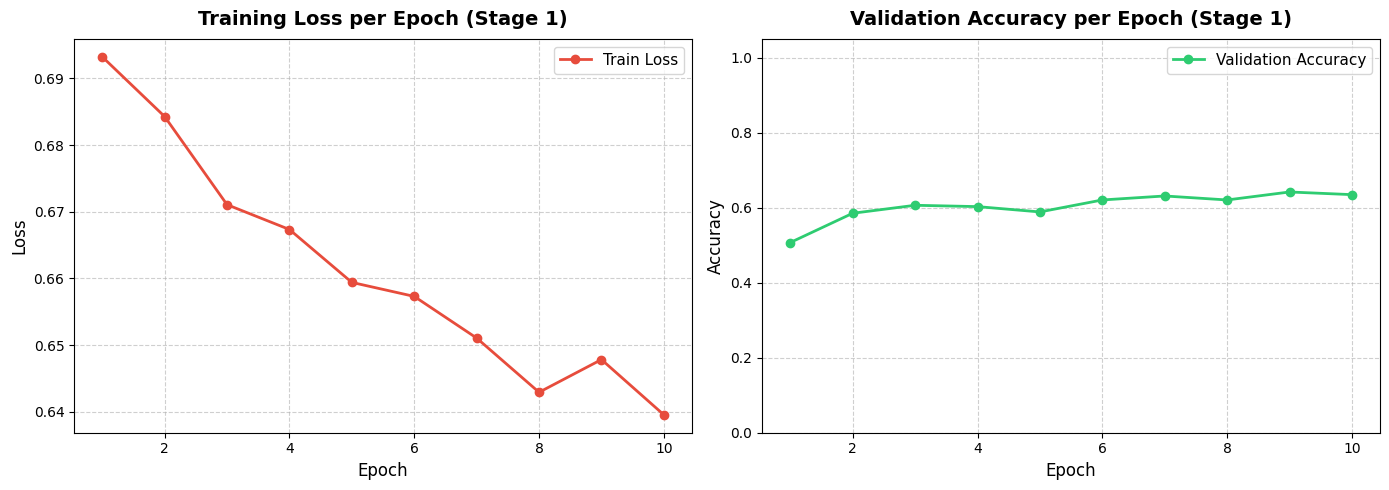

Guesses (Before Fine-Tuning):
Message #1
  Guess: USER 3
  Confidence by users:
    USER 1: 47.94%
    USER 3: 52.06%
Message #2
  Guess: USER 3
  Confidence by users:
    USER 1: 48.23%
    USER 3: 51.77%
Message #3
  Guess: USER 3
  Confidence by users:
    USER 1: 41.82%
    USER 3: 58.18%
Message #4
  Guess: USER 1
  Confidence by users:
    USER 1: 61.72%
    USER 3: 38.28%
Message #5
  Guess: USER 1
  Confidence by users:
    USER 1: 75.11%
    USER 3: 24.89%
Message #6
  Guess: USER 3
  Confidence by users:
    USER 1: 44.75%
    USER 3: 55.25%
Message #7
  Guess: USER 3
  Confidence by users:
    USER 1: 42.32%
    USER 3: 57.68%
Message #8
  Guess: USER 1
  Confidence by users:
    USER 1: 50.91%
    USER 3: 49.09%
Message #9
  Guess: USER 1
  Confidence by users:
    USER 1: 64.36%
    USER 3: 35.64%
Message #10
  Guess: USER 1
  Confidence by users:
    USER 1: 55.51%
    USER 3: 44.49%
Message #11
  Guess: USER 1
  Confidence by users:
    USER 1: 62.99%
    USER 3: 37.01%


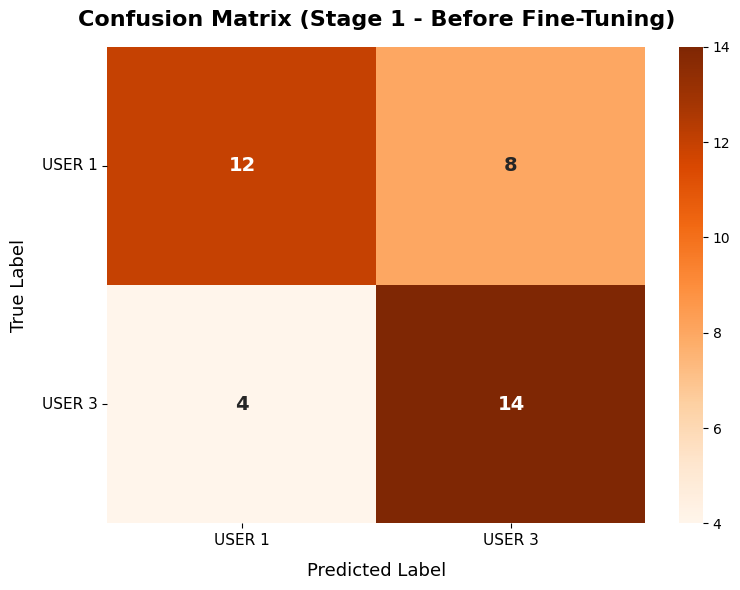

Stage 2: Fine-Tuning


100%|██████████| 36/36 [00:21<00:00,  1.69it/s]


1 0.6151631457938088 0.6808510422706604


100%|██████████| 36/36 [00:20<00:00,  1.76it/s]


2 0.560327244301637 0.7127659320831299


...

10 0.2184211661418279 0.7801418304443359


100%|██████████| 36/36 [00:20<00:00,  1.75it/s]


11 0.21479278927048048 0.7801418304443359


100%|██████████| 36/36 [00:20<00:00,  1.72it/s]


12 0.16658621405561766 0.7765957713127136


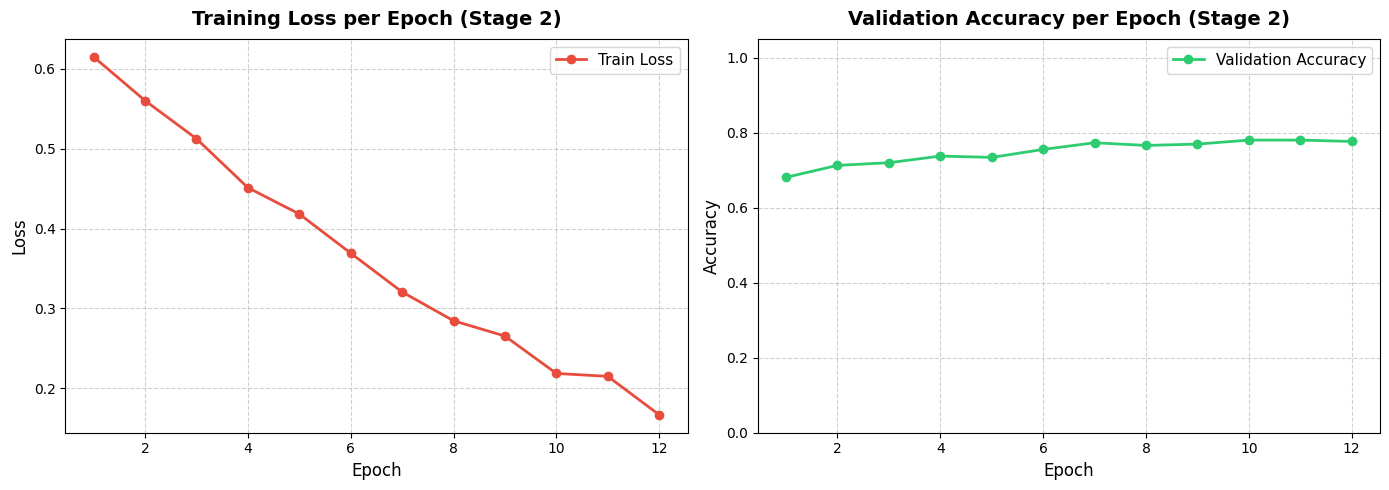

Guesses (After Fine-Tuning):
Message #1
  Guess: USER 1
  Confidence by users:
    USER 1: 94.23%
    USER 3: 5.77%
Message #2
  Guess: USER 1
  Confidence by users:
    USER 1: 70.09%
    USER 3: 29.91%
Message #3
  Guess: USER 3
  Confidence by users:
    USER 1: 34.17%
    USER 3: 65.83%
Message #4
  Guess: USER 1
  Confidence by users:
    USER 1: 94.84%
    USER 3: 5.16%
Message #5
  Guess: USER 1
  Confidence by users:
    USER 1: 99.68%
    USER 3: 0.32%
Message #6
  Guess: USER 1
  Confidence by users:
    USER 1: 98.96%
    USER 3: 1.04%
Message #7
  Guess: USER 3
  Confidence by users:
    USER 1: 8.06%
    USER 3: 91.94%
Message #8
  Guess: USER 1
  Confidence by users:
    USER 1: 80.57%
    USER 3: 19.43%
Message #9
  Guess: USER 1
  Confidence by users:
    USER 1: 97.95%
    USER 3: 2.05%
Message #10
  Guess: USER 1
  Confidence by users:
    USER 1: 72.68%
    USER 3: 27.32%
Message #11
  Guess: USER 1
  Confidence by users:
    USER 1: 99.31%
    USER 3: 0.69%
Message 

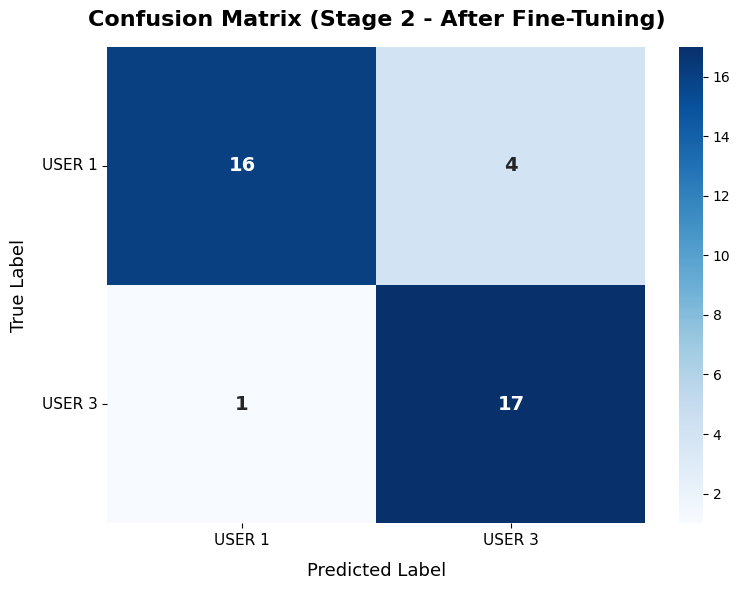

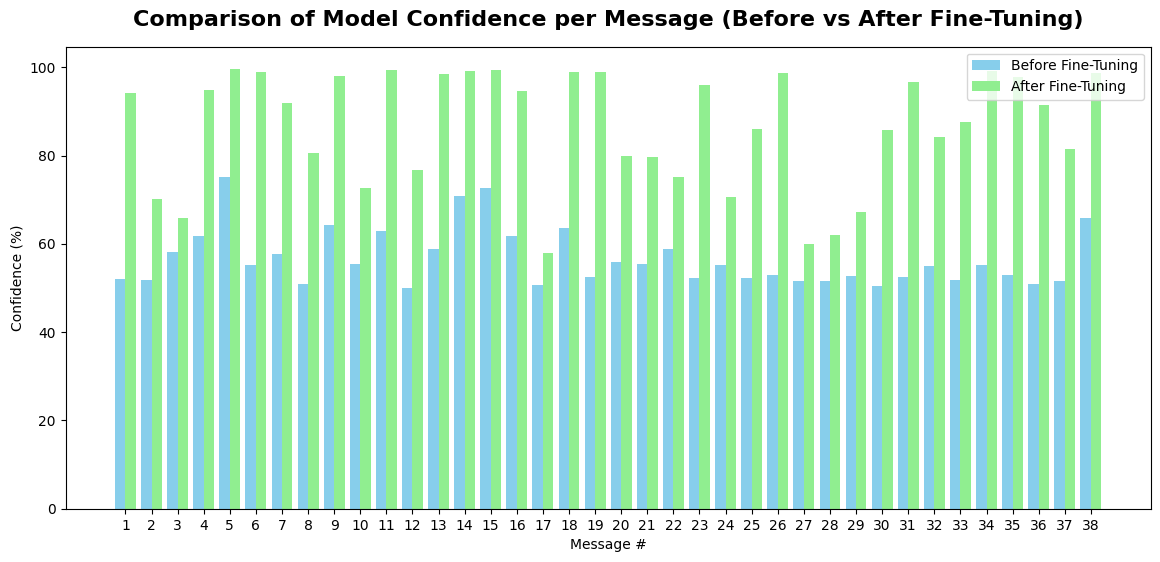

In [28]:
run_code_simulation(True, False, True)

**The model(Before Fine-Tuning) acheived a validation accuracy of 63% and 68% in the test accuracy and the model(After Fine-Tuning) was able to reach 78% val accuracy and 87% test accuracy. Also, the confidence of a lot of the messages exceeds 90%. However, it does seem to find it slightly harder to distinguish USER 1 and USER 3 apart.**

Simulating with 2 users: ['USER 2', 'USER 3']
Answers to test data: ['USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 2', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3', 'USER 3']
Train data:
                         text   label
0                  Good night  USER 2
1             Спасибо, быстро  USER 2
2    Хахахахахах надо сделать  USER 2
3  А это курс который я нашёл  USER 2
4                      Sonion  USER 2
Test data:
                                                text
0     Хорошо, тогда удачи тебе теперь на информатике
1  Помнишь видео с роблоксом? Вот я такое буду сн...
2  Скиньте пожалуйста кто-нибудь 10 рублей на проезд
3  Сделай из этого стикер еще один, пж когда сможешь
4               Ничего страшного 95+ это очень круто


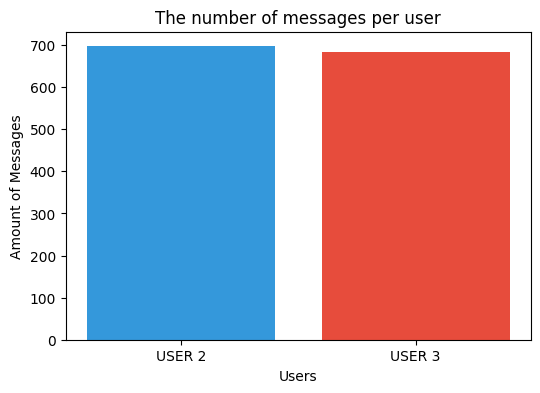

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

Stage 1(Before Fine-Tuning):


100%|██████████| 35/35 [00:06<00:00,  5.62it/s]


1 0.699732198034014 0.49637681245803833


...

8 0.6667646697589329 0.6413043737411499


100%|██████████| 35/35 [00:06<00:00,  5.69it/s]


9 0.6633435113089425 0.5905796885490417


100%|██████████| 35/35 [00:06<00:00,  5.56it/s]


10 0.6640653831618173 0.5688405632972717


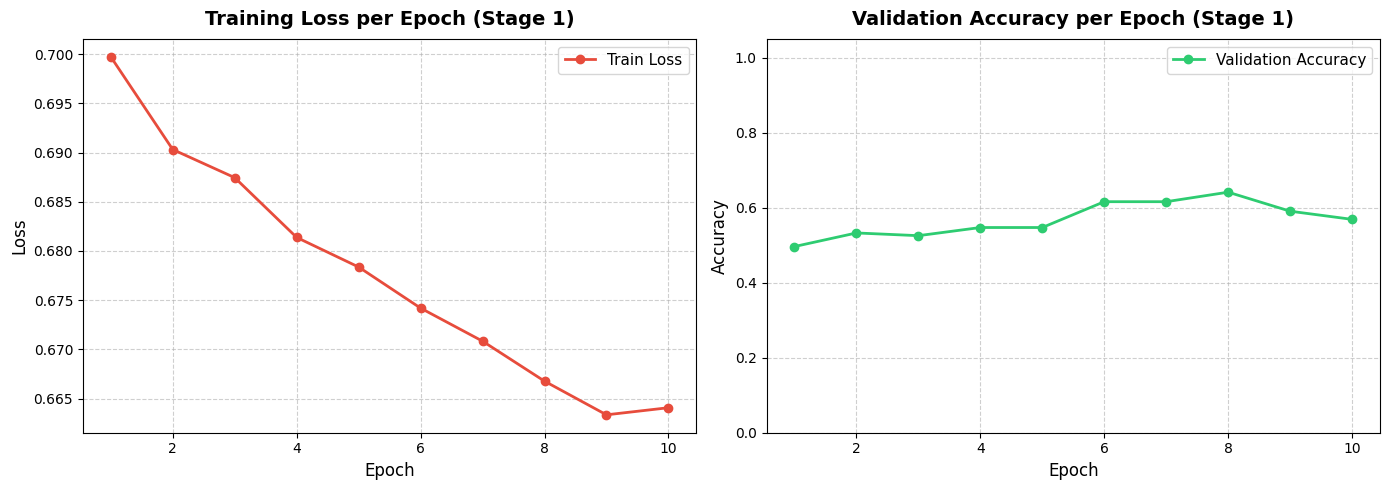

Guesses (Before Fine-Tuning):
Message #1
  Guess: USER 2
  Confidence by users:
    USER 2: 50.06%
    USER 3: 49.94%
Message #2
  Guess: USER 2
  Confidence by users:
    USER 2: 57.98%
    USER 3: 42.02%
Message #3
  Guess: USER 2
  Confidence by users:
    USER 2: 51.85%
    USER 3: 48.15%
Message #4
  Guess: USER 2
  Confidence by users:
    USER 2: 53.87%
    USER 3: 46.13%
Message #5
  Guess: USER 2
  Confidence by users:
    USER 2: 60.47%
    USER 3: 39.53%
Message #6
  Guess: USER 3
  Confidence by users:
    USER 2: 49.79%
    USER 3: 50.21%
Message #7
  Guess: USER 2
  Confidence by users:
    USER 2: 52.56%
    USER 3: 47.44%
Message #8
  Guess: USER 3
  Confidence by users:
    USER 2: 49.77%
    USER 3: 50.23%
Message #9
  Guess: USER 2
  Confidence by users:
    USER 2: 66.69%
    USER 3: 33.31%
Message #10
  Guess: USER 2
  Confidence by users:
    USER 2: 50.06%
    USER 3: 49.94%
Message #11
  Guess: USER 2
  Confidence by users:
    USER 2: 52.1%
    USER 3: 47.9%
Me

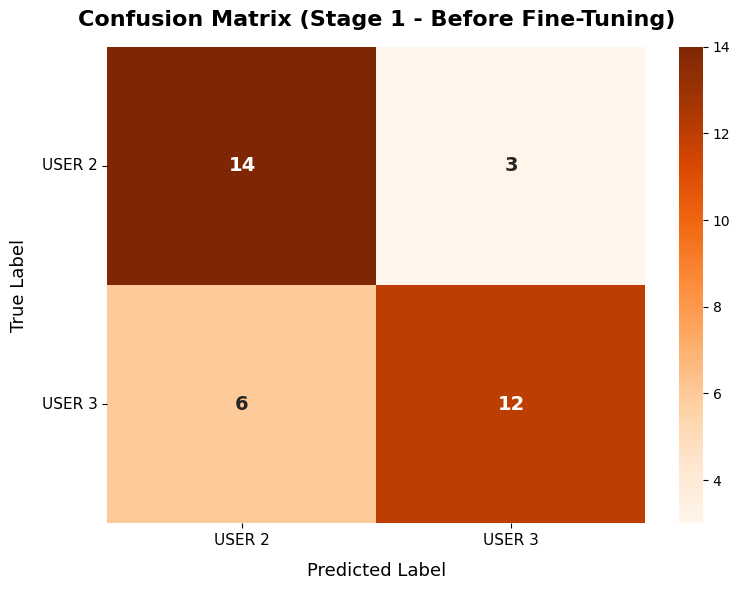

Stage 2: Fine-Tuning


100%|██████████| 35/35 [00:20<00:00,  1.70it/s]


1 0.6603628396987915 0.6630434989929199


100%|██████████| 35/35 [00:19<00:00,  1.77it/s]


2 0.6433580466679164 0.70652174949646


...

10 0.4031832039356232 0.75


100%|██████████| 35/35 [00:20<00:00,  1.75it/s]


11 0.36332552007266455 0.77173912525177


100%|██████████| 35/35 [00:19<00:00,  1.77it/s]


12 0.32971310913562774 0.7355072498321533


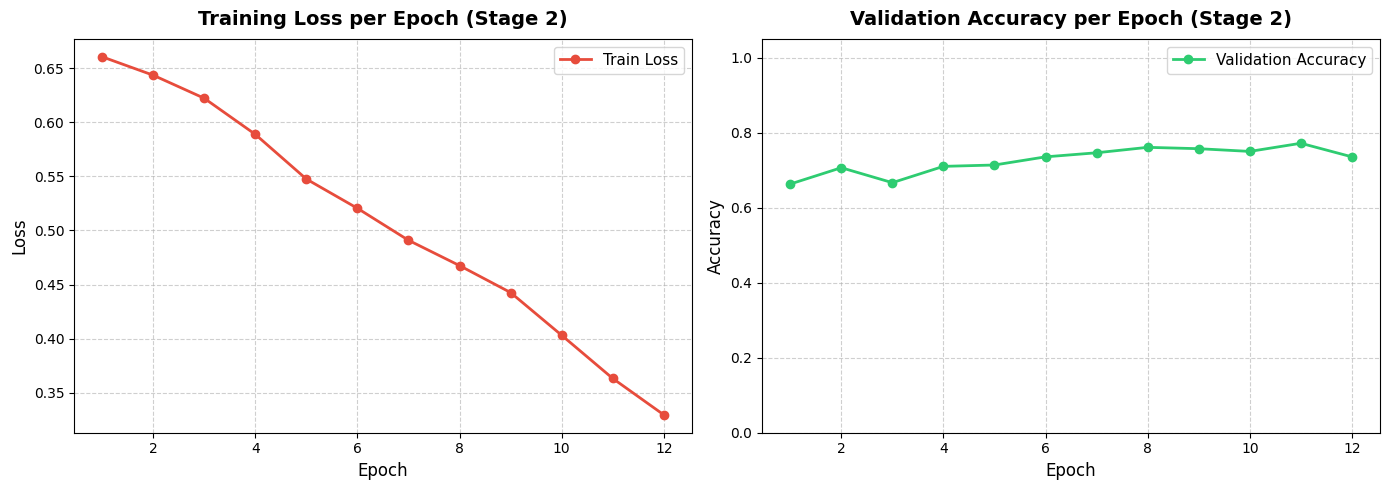

Guesses (After Fine-Tuning):
Message #1
  Guess: USER 2
  Confidence by users:
    USER 2: 97.79%
    USER 3: 2.21%
Message #2
  Guess: USER 2
  Confidence by users:
    USER 2: 87.86%
    USER 3: 12.14%
Message #3
  Guess: USER 2
  Confidence by users:
    USER 2: 91.0%
    USER 3: 9.0%
Message #4
  Guess: USER 3
  Confidence by users:
    USER 2: 29.67%
    USER 3: 70.33%
Message #5
  Guess: USER 2
  Confidence by users:
    USER 2: 92.71%
    USER 3: 7.29%
Message #6
  Guess: USER 2
  Confidence by users:
    USER 2: 97.72%
    USER 3: 2.28%
Message #7
  Guess: USER 2
  Confidence by users:
    USER 2: 88.39%
    USER 3: 11.61%
Message #8
  Guess: USER 2
  Confidence by users:
    USER 2: 81.97%
    USER 3: 18.03%
Message #9
  Guess: USER 2
  Confidence by users:
    USER 2: 97.05%
    USER 3: 2.95%
Message #10
  Guess: USER 3
  Confidence by users:
    USER 2: 33.89%
    USER 3: 66.11%
Message #11
  Guess: USER 2
  Confidence by users:
    USER 2: 90.34%
    USER 3: 9.66%
Message #

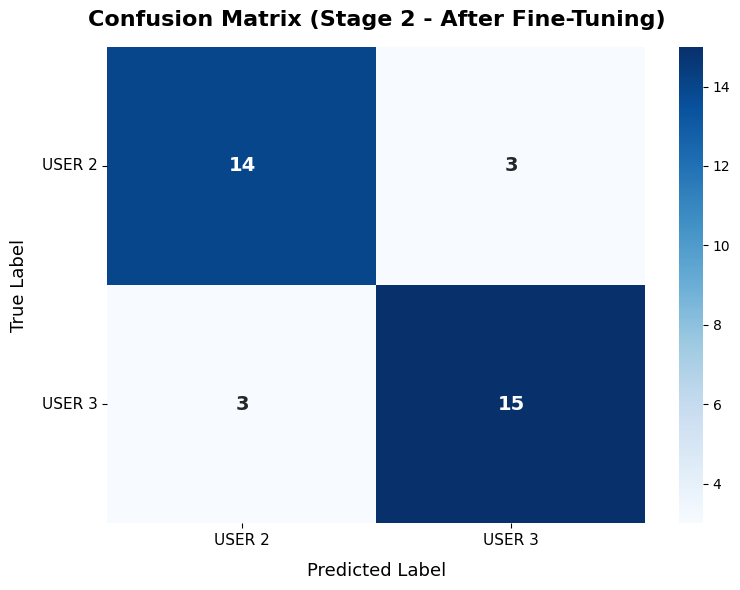

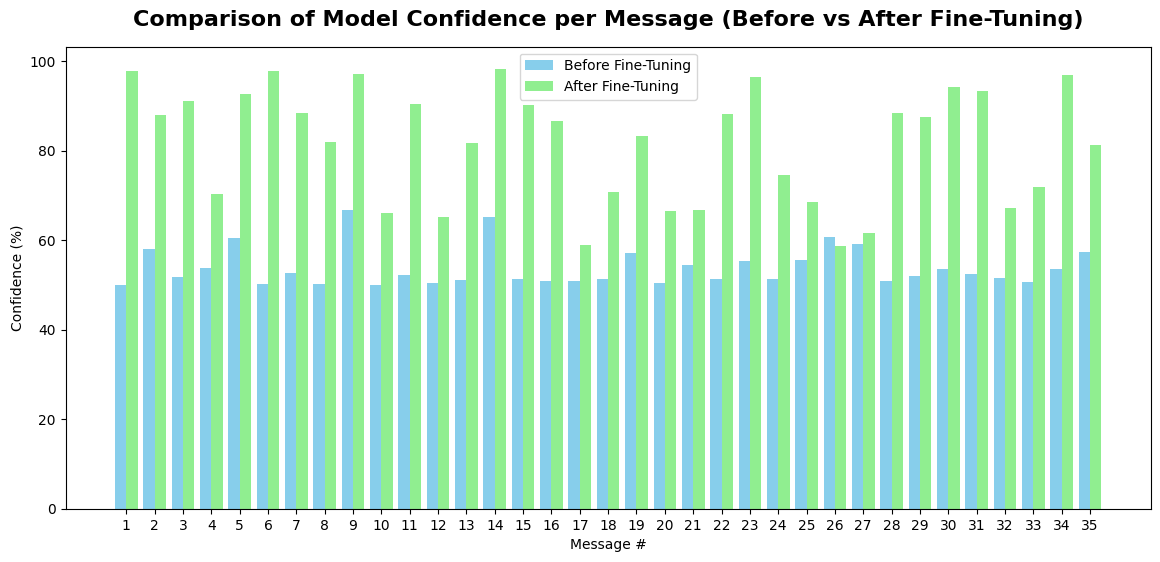

In [29]:
run_code_simulation(False, True, True)

**The model(Before Fine-Tuning) acheived a validation accuracy of 64% and 74% in the test accuracy and the model(After Fine-Tuning) was able to reach 77% val accuracy and 83% test accuracy. This illustrates that the model had the hardest time telling the difference between USER 2 and USER 3**

# Conclusion:
**In conclusion, the model managed to acheive a score of 82% with 3 USERS(which is much higher than the baseline of 33.33%) and 95%, 87%, and 83% test accuracy with 2 people(USER1vsUSER2,USER1vsUSER3,USER2vsUSER3), which is a lot higher than 50%(random chance).**

**This proves that the model managed to understand the key differences between every person and pinpoint what words, phrases, or punctuation every person uses and assessed that to acheive a high accuracy.**

**Also, one of the reasons the model can't reach an accuracy score close to 99-100%(which will indicate that there has probably been a Data Leakage) is that some messages are too universal(which means anyone could have said it) or sound like what another person would say.**

**I believe that if I had more data(2000+ messages per person) and also added some context(which means like the previous 3-5 sentences) the model could acheive a score of 95%+.**